In [5]:
!pip install optuna -q

Carregando dados do UTD-MHAD...
Shape X_train: (457, 125, 66)
Shape X_val: (145, 125, 66)
Shape X_test: (623, 125, 66)
Número de classes (Ações): 27

Calculando pesos de classes...

Pré-computando imagens URP (isso será feito apenas uma vez). Aguarde...
Pré-computação finalizada!

EXPERIMENTO 1: TREINANDO ARQUITETURA BASE
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.0503 - loss: 10.2068 - val_accuracy: 0.0690 - val_loss: 9.7498 - learning_rate: 1.0000e-04
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.1729 - loss: 9.2147 - val_accuracy: 0.1034 - val_loss: 9.4207 - learning_rate: 1.0000e-04
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.2845 - loss: 8.6864 - val_accuracy: 0.1448 - val_loss: 9.1397 - learning_rate: 1.0000e-04
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3764 - loss: 8.2008 - val_accuracy: 0.1724 - val_loss: 8.8787 - learning_rate: 1.0000e-04
Epoch

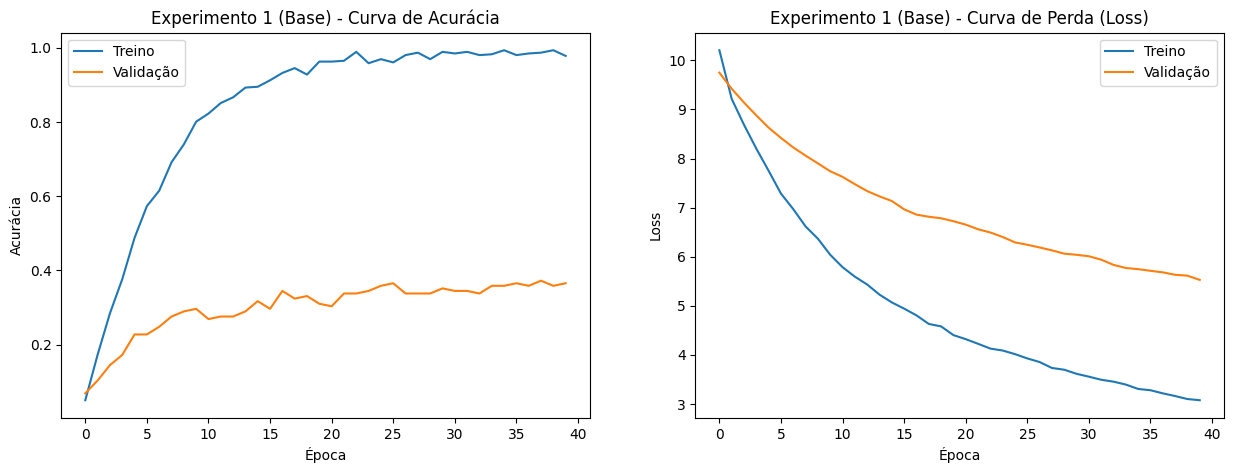


Gerando previsões no conjunto de teste para Experimento 1 (Base)...
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 356ms/step
Calculando métricas com Bootstrap (N=1000)...

MÉTRICAS MÉDIAS (BOOTSTRAP):
  Acurácia: 0.4723 ± 0.0195
  F1-Score (Macro): 0.4492 ± 0.0189

Relatório de Classificação - Experimento 1 (Base):
              precision    recall  f1-score   support

           0       0.41      0.79      0.54        19
           1       0.50      0.45      0.47        20
           2       0.59      0.95      0.73        20
           3       0.52      0.75      0.61        20
           4       0.19      0.36      0.25        14
           5       0.67      0.63      0.65        19
           6       0.40      0.27      0.32        15
           7       0.50      0.09      0.15        22
           8       0.43      0.57      0.49        23
           9       0.39      0.54      0.46        24
          10       0.60      0.52      0.56        29
          11       0.50      0.60      0.55     

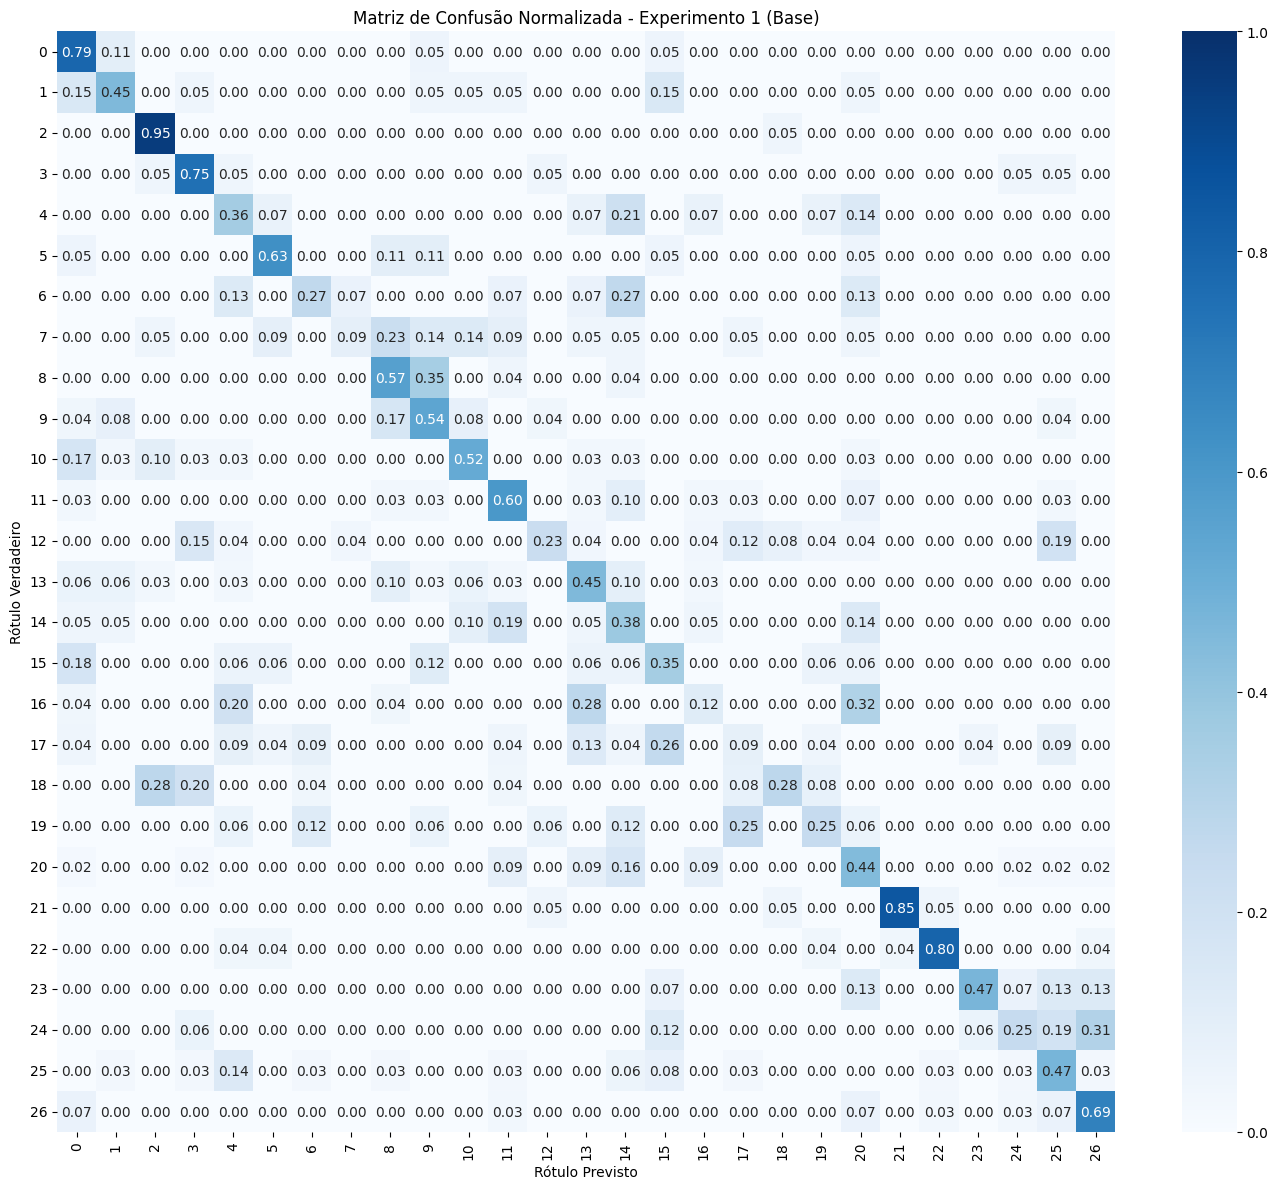


Gerando amostras de Recurrence Plots (URP) para Experimento 1 (Base)...


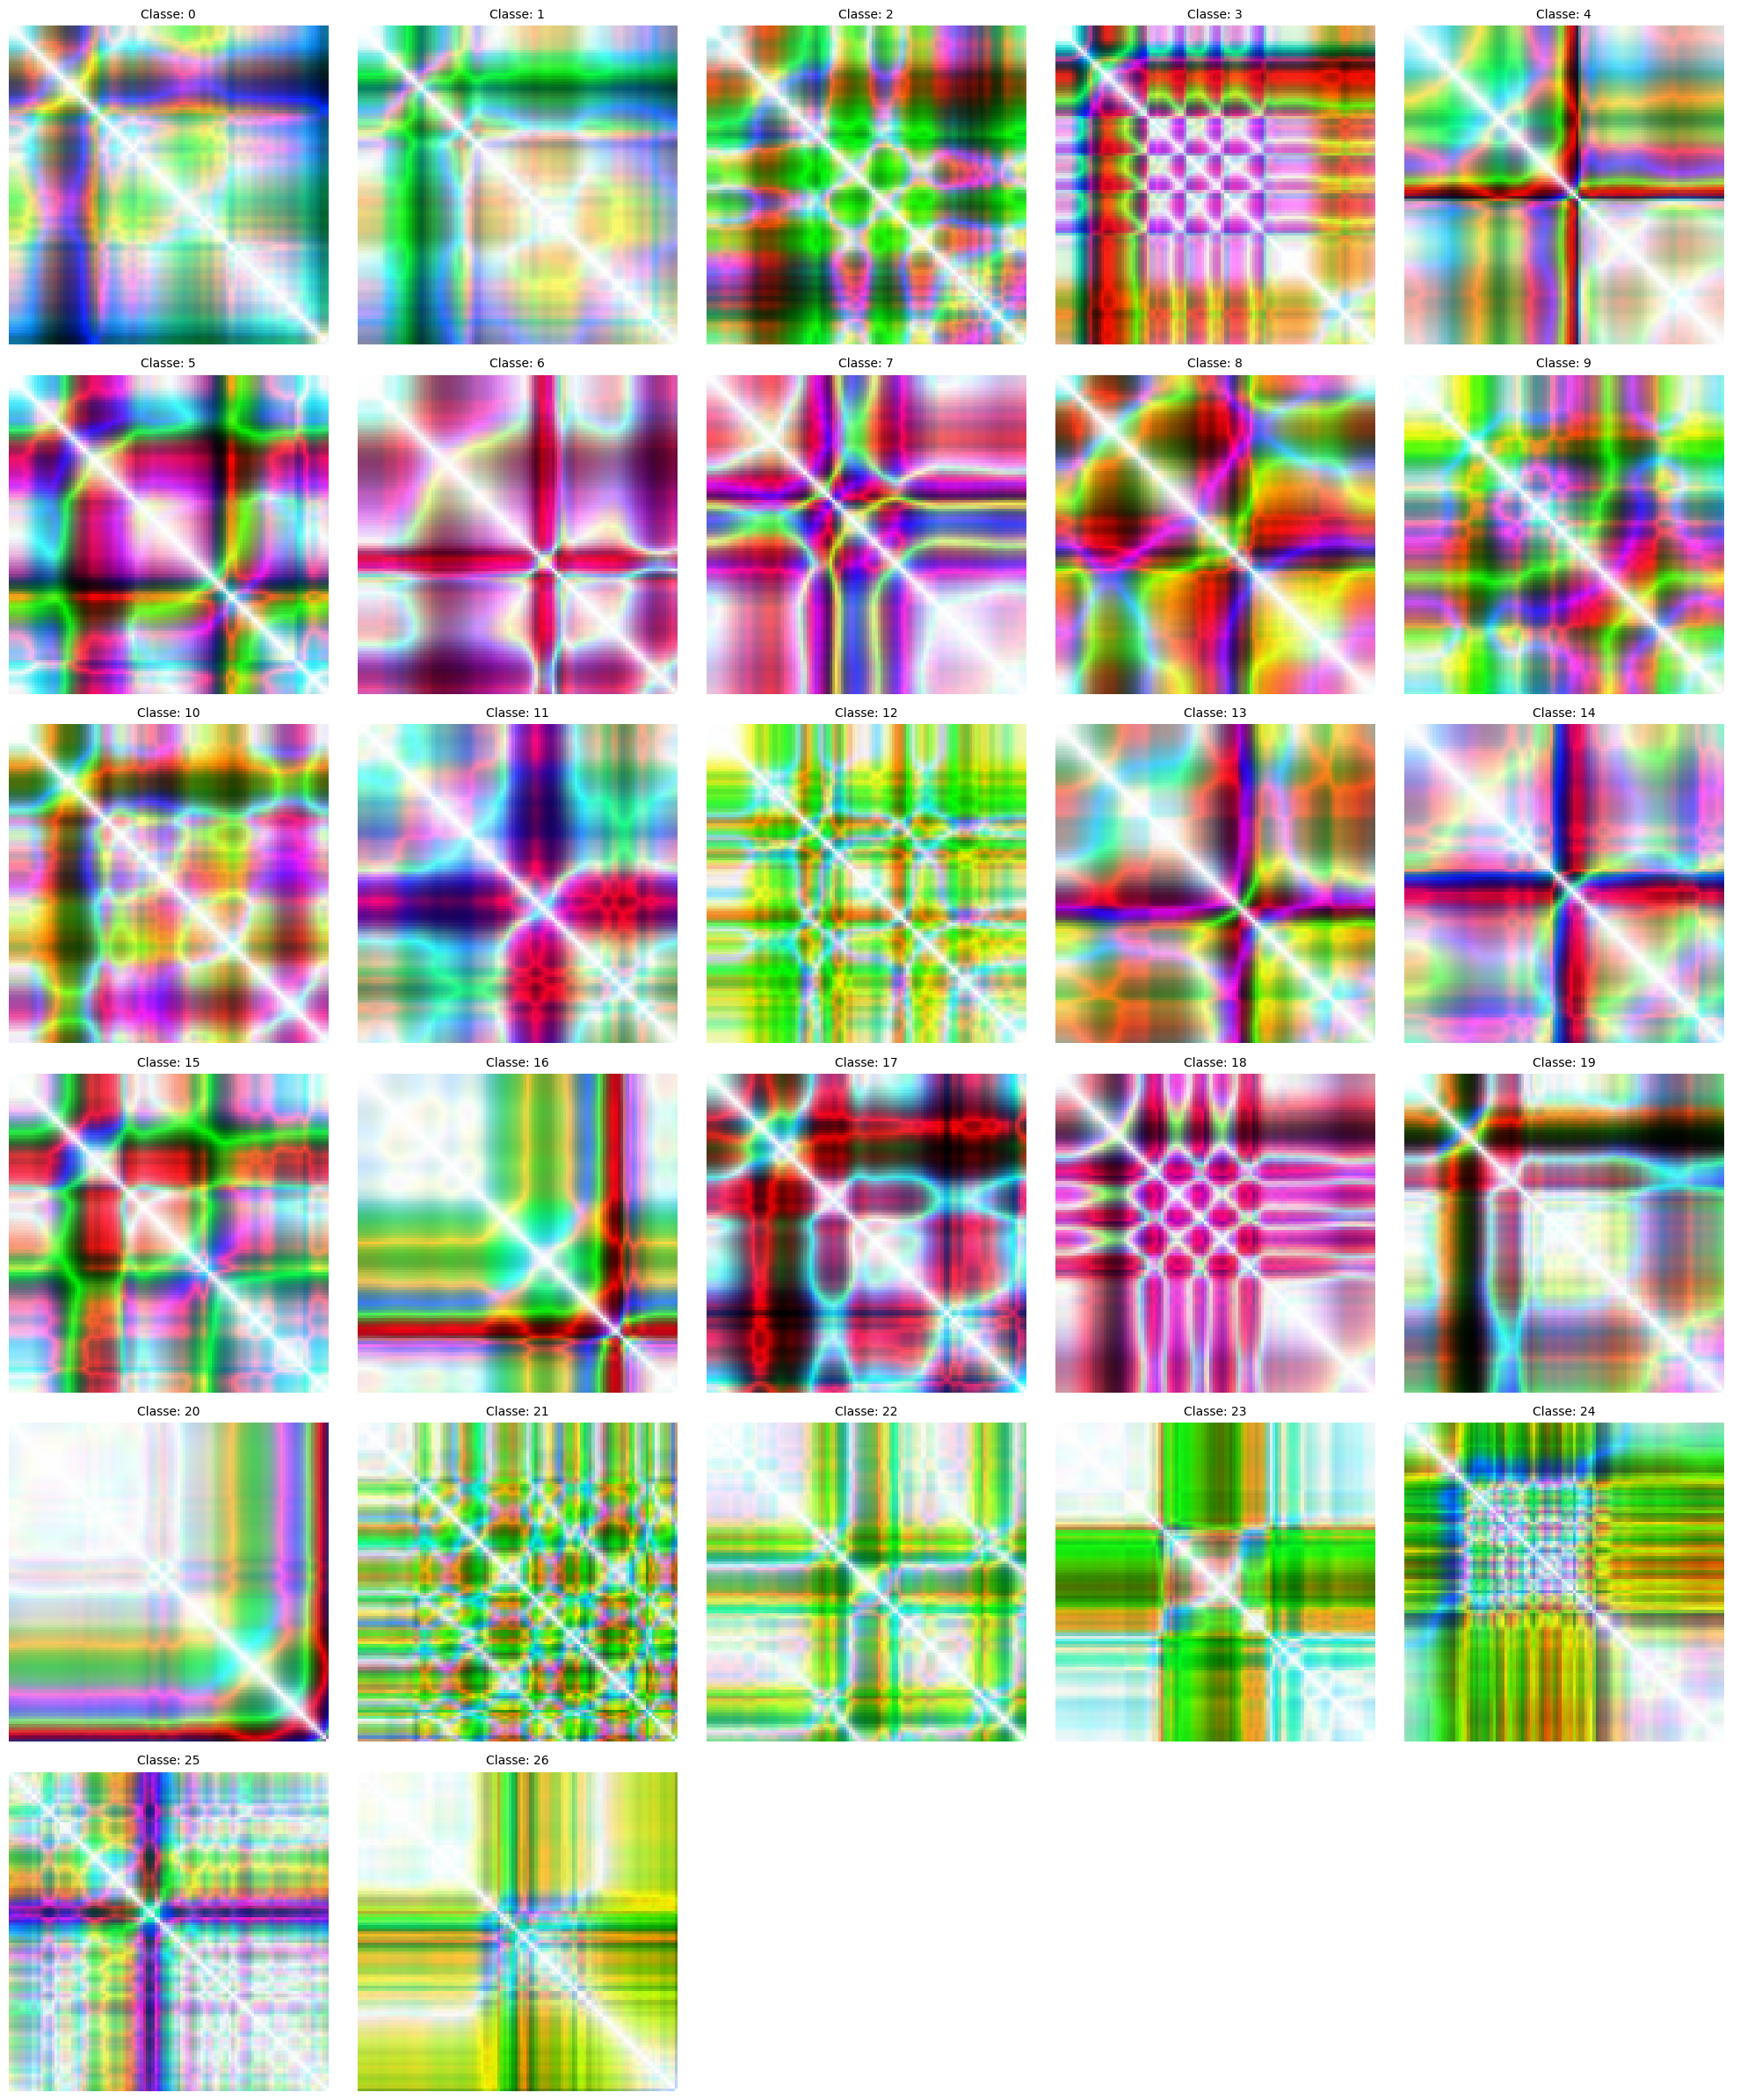

In [6]:
# ==========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================
import math
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks, regularizers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import optuna

# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

# ==========================================
# 2. CARREGAMENTO DOS DADOS (.npz)
# ==========================================
DATA_PATH = "/content/utd_mhad_for_rp.npz"

print("Carregando dados do UTD-MHAD...")
data = np.load(DATA_PATH)
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

num_classes = len(np.unique(y_train))
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val: {X_val.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Número de classes (Ações): {num_classes}")

# ==========================================
# 3. BALANCEAMENTO DE CLASSES
# ==========================================
print("\nCalculando pesos de classes...")
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
TETO_MAXIMO = 5.0
for k in class_weights_dict.keys():
    if class_weights_dict[k] > TETO_MAXIMO:
        class_weights_dict[k] = TETO_MAXIMO

# ==========================================
# 4. PRÉ-COMPUTAÇÃO DAS FEATURES (OTIMIZADO PARA CPU/RAM)
# ==========================================
idx_x = [0, 3]
idx_y = [1, 4]
idx_z = [2, 5]
idx_others = list(range(6, 66))

def preprocess_data(X, target_img_size=(112, 112)):
    n_samples = len(X)
    X_1d = X[:, :, idx_others]
    X_img = np.zeros((n_samples, target_img_size[0], target_img_size[1], 3), dtype=np.float32)

    for i in range(n_samples):
        window = X[i]
        dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
        dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
        dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

        img = np.stack([dist_r, dist_g, dist_b], axis=-1)
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)

        img = (1.0 - img) ** 3
        img_resized = cv2.resize(img, target_img_size, interpolation=cv2.INTER_LINEAR)
        img_preprocessed = applications.resnet50.preprocess_input(img_resized * 255.0)
        X_img[i] = img_preprocessed

    return X_img, X_1d

print("\nPré-computando imagens URP (isso será feito apenas uma vez). Aguarde...")
X_train_img, X_train_1d = preprocess_data(X_train)
X_val_img, X_val_1d = preprocess_data(X_val)
X_test_img, X_test_1d = preprocess_data(X_test)
print("Pré-computação finalizada!")

# ============================================================================
# FUNÇÃO DE AVALIAÇÃO PADRONIZADA (MÉTRICAS, BOOTSTRAP, GRÁFICOS)
# ============================================================================
def evaluate_experiment(model, history, exp_name):
    print(f"\n{'='*60}")
    print(f"AVALIAÇÃO DO {exp_name.upper()}")
    print(f"{'='*60}")

    # 1. Curva de Aprendizado
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(history.history['accuracy'], label='Treino')
    axes[0].plot(history.history['val_accuracy'], label='Validação')
    axes[0].set_title(f'{exp_name} - Curva de Acurácia')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Acurácia')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Treino')
    axes[1].plot(history.history['val_loss'], label='Validação')
    axes[1].set_title(f'{exp_name} - Curva de Perda (Loss)')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.show()

    # Previsões
    print(f"\nGerando previsões no conjunto de teste para {exp_name}...")
    y_pred_probs = model.predict([X_test_img, X_test_1d], batch_size=32)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = y_test

    # 2. Bootstrap (Acurácia e F1-Score)
    n_iterations = 1000
    acc_scores = []
    f1_scores = []
    print(f"Calculando métricas com Bootstrap (N={n_iterations})...")
    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)), replace=True)
        y_true_b = y_true[indices]
        y_pred_b = y_pred[indices]
        acc_scores.append(accuracy_score(y_true_b, y_pred_b))
        f1_scores.append(f1_score(y_true_b, y_pred_b, average='macro'))

    mean_acc, std_acc = np.mean(acc_scores), np.std(acc_scores)
    mean_f1, std_f1 = np.mean(f1_scores), np.std(f1_scores)

    print("\nMÉTRICAS MÉDIAS (BOOTSTRAP):")
    print(f"  Acurácia: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"  F1-Score (Macro): {mean_f1:.4f} ± {std_f1:.4f}")

    # 3. Relatório de Classificação
    target_names = [str(le.inverse_transform([i])[0]) for i in range(num_classes)]
    print(f"\nRelatório de Classificação - {exp_name}:")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # 4. Matriz de Confusão
    plt.figure(figsize=(14, 12))
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=target_names, yticklabels=target_names, vmin=0.0, vmax=1.0)
    plt.title(f'Matriz de Confusão Normalizada - {exp_name}')
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Previsto')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 5. Recurrence Plots (URP)
    print(f"\nGerando amostras de Recurrence Plots (URP) para {exp_name}...")
    unique_classes = np.unique(y_train)
    cols = 5
    rows = int(np.ceil(num_classes / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = axes.flatten()

    for i, cls in enumerate(unique_classes):
        sample_idx = np.where(y_train == cls)[0][0]
        window = X_train[sample_idx]

        dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
        dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
        dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

        img = np.stack([dist_r, dist_g, dist_b], axis=-1)
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)
        img = (1.0 - img) ** 3
        img_resized = cv2.resize(img, (112, 112), interpolation=cv2.INTER_LINEAR)

        original_label = le.inverse_transform([cls])[0]
        ax = axes[i]
        ax.imshow(img_resized)
        ax.set_title(f'Classe: {original_label}', fontsize=10)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# ============================================================================
# EXPERIMENTO 1: MODELO BASE (APENAS PESOS BALANCEADOS)
# ============================================================================
print("\n" + "="*50)
print("EXPERIMENTO 1: TREINANDO ARQUITETURA BASE")
print("="*50)

def build_utd_late_fusion(num_classes, num_other_features=len(idx_others), window_size=100):
    l2_reg = regularizers.l2(0.01)

    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    input_1d = layers.Input(shape=(window_size, num_other_features), name="input_1d_series")
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2_reg)(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2_reg)(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(x_1d)

    merged = layers.concatenate([x_img, x_1d])
    z = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(merged)
    z = layers.Dropout(0.4)(z)
    output = layers.Dense(num_classes, activation='softmax')(z)

    model = models.Model(inputs=[input_img, input_1d], outputs=output)
    return model

model_exp1 = build_utd_late_fusion(num_classes=num_classes, window_size=125)
model_exp1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_exp1 = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr_exp1 = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history_exp1 = model_exp1.fit(
    x=[X_train_img, X_train_1d],
    y=y_train,
    validation_data=([X_val_img, X_val_1d], y_val),
    batch_size=32,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_exp1, reduce_lr_exp1],
    verbose=1
)

# Chama a função de avaliação completa para o Experimento 1
evaluate_experiment(model_exp1, history_exp1, "Experimento 1 (Base)")

[I 2026-05-01 22:09:41,381] A new study created in memory with name: no-name-3f43253c-f805-4e1c-950d-47196a8d8860



EXPERIMENTO 2: OTIMIZAÇÃO DE HIPERPARÂMETROS (OPTUNA)


[I 2026-05-01 22:10:41,029] Trial 0 finished with value: 0.06896551698446274 and parameters: {'lr': 1.090814013806487e-05, 'dropout_rate': 0.22461475513216814, 'dense_units': 64}. Best is trial 0 with value: 0.06896551698446274.
[I 2026-05-01 22:11:28,622] Trial 1 finished with value: 0.13793103396892548 and parameters: {'lr': 1.1250432267761042e-05, 'dropout_rate': 0.3088144374492669, 'dense_units': 256}. Best is trial 1 with value: 0.13793103396892548.
[I 2026-05-01 22:12:16,970] Trial 2 finished with value: 0.3448275923728943 and parameters: {'lr': 0.0002525022075502471, 'dropout_rate': 0.26943697228694985, 'dense_units': 128}. Best is trial 2 with value: 0.3448275923728943.
[I 2026-05-01 22:13:04,980] Trial 3 finished with value: 0.17241379618644714 and parameters: {'lr': 1.974520453908783e-05, 'dropout_rate': 0.30438253412158395, 'dense_units': 128}. Best is trial 2 with value: 0.3448275923728943.
[I 2026-05-01 22:13:53,758] Trial 4 finished with value: 0.08965517580509186 and par


Resultados da Busca do Optuna:
Melhor Trial:
  Valor (Val Accuracy): 0.3448
  Parâmetros:
    lr: 0.0002525022075502471
    dropout_rate: 0.26943697228694985
    dense_units: 128

**************************************************
TREINANDO O MELHOR MODELO ENCONTRADO PELO OPTUNA
**************************************************
Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.1028 - loss: 9.7999 - val_accuracy: 0.1034 - val_loss: 9.3584 - learning_rate: 2.5250e-04
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.3523 - loss: 8.3747 - val_accuracy: 0.1586 - val_loss: 8.7074 - learning_rate: 2.5250e-04
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5646 - loss: 7.3342 - val_accuracy: 0.2690 - val_loss: 8.1422 - learning_rate: 2.5250e-04
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7133 - loss: 6.4317 - val_accuracy: 0.3103 - val_loss: 7.7401 - learning_rate: 2.5250e-04
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/ste

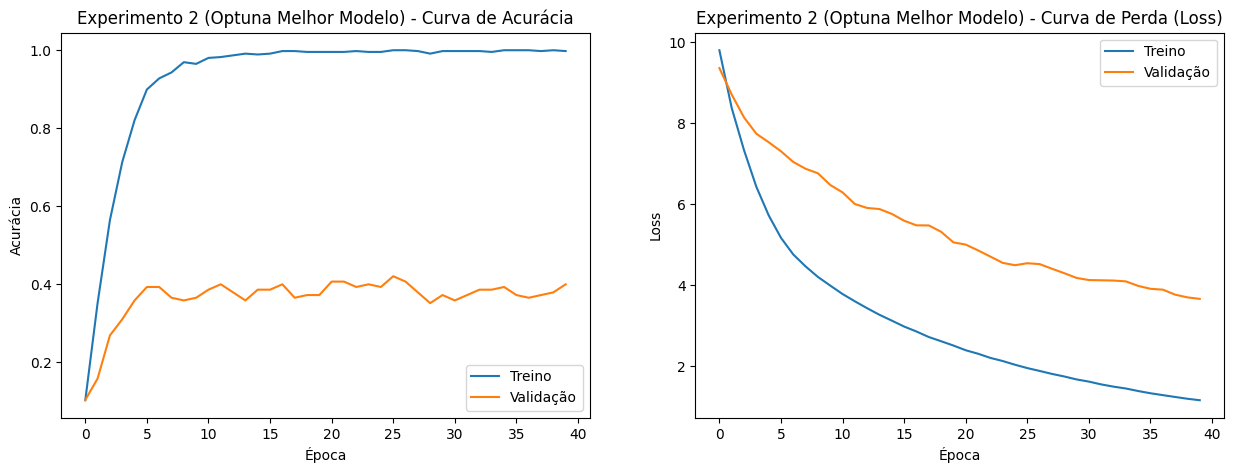


Gerando previsões no conjunto de teste para Experimento 2 (Optuna Melhor Modelo)...
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step
Calculando métricas com Bootstrap (N=1000)...

MÉTRICAS MÉDIAS (BOOTSTRAP):
  Acurácia: 0.4923 ± 0.0195
  F1-Score (Macro): 0.4544 ± 0.0184

Relatório de Classificação - Experimento 2 (Optuna Melhor Modelo):
              precision    recall  f1-score   support

           0       0.37      0.84      0.52        19
           1       0.38      0.50      0.43        20
           2       0.48      1.00      0.65        20
           3       0.58      0.75      0.65        20
           4       0.26      0.50      0.34        14
           5       0.46      0.68      0.55        19
           6       0.21      0.40      0.27        15
           7       0.33      0.05      0.08        22
           8       0.26      0.30      0.28        23
           9       0.52      0.50      0.51        24
          10       0.47      0.59      0.52        29
          11    

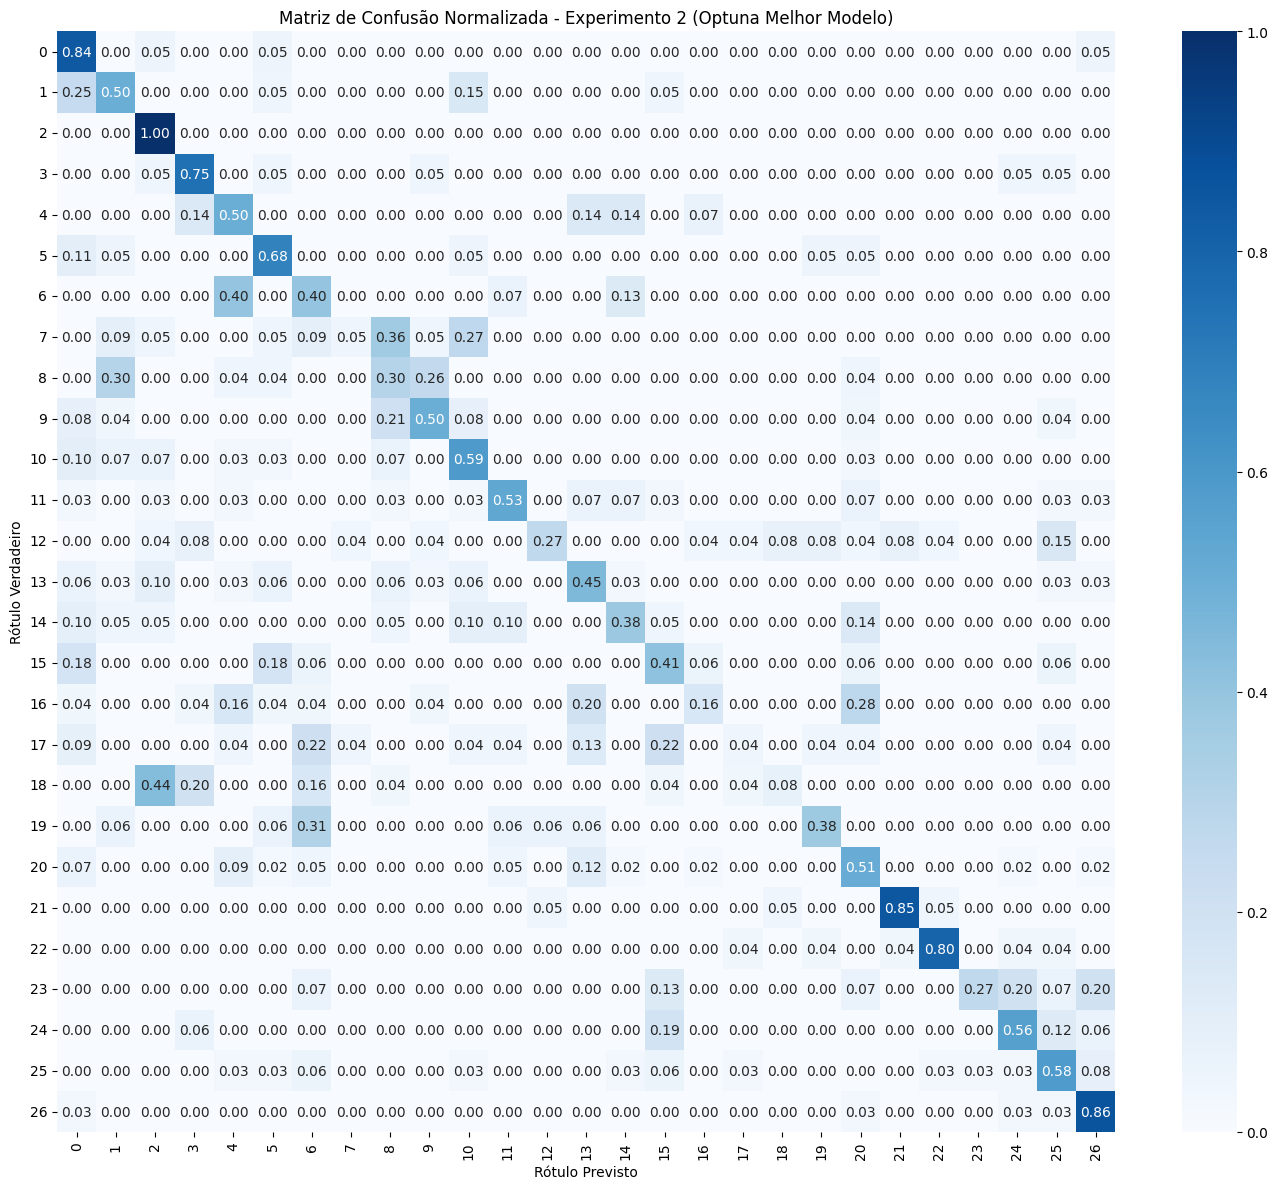


Gerando amostras de Recurrence Plots (URP) para Experimento 2 (Optuna Melhor Modelo)...


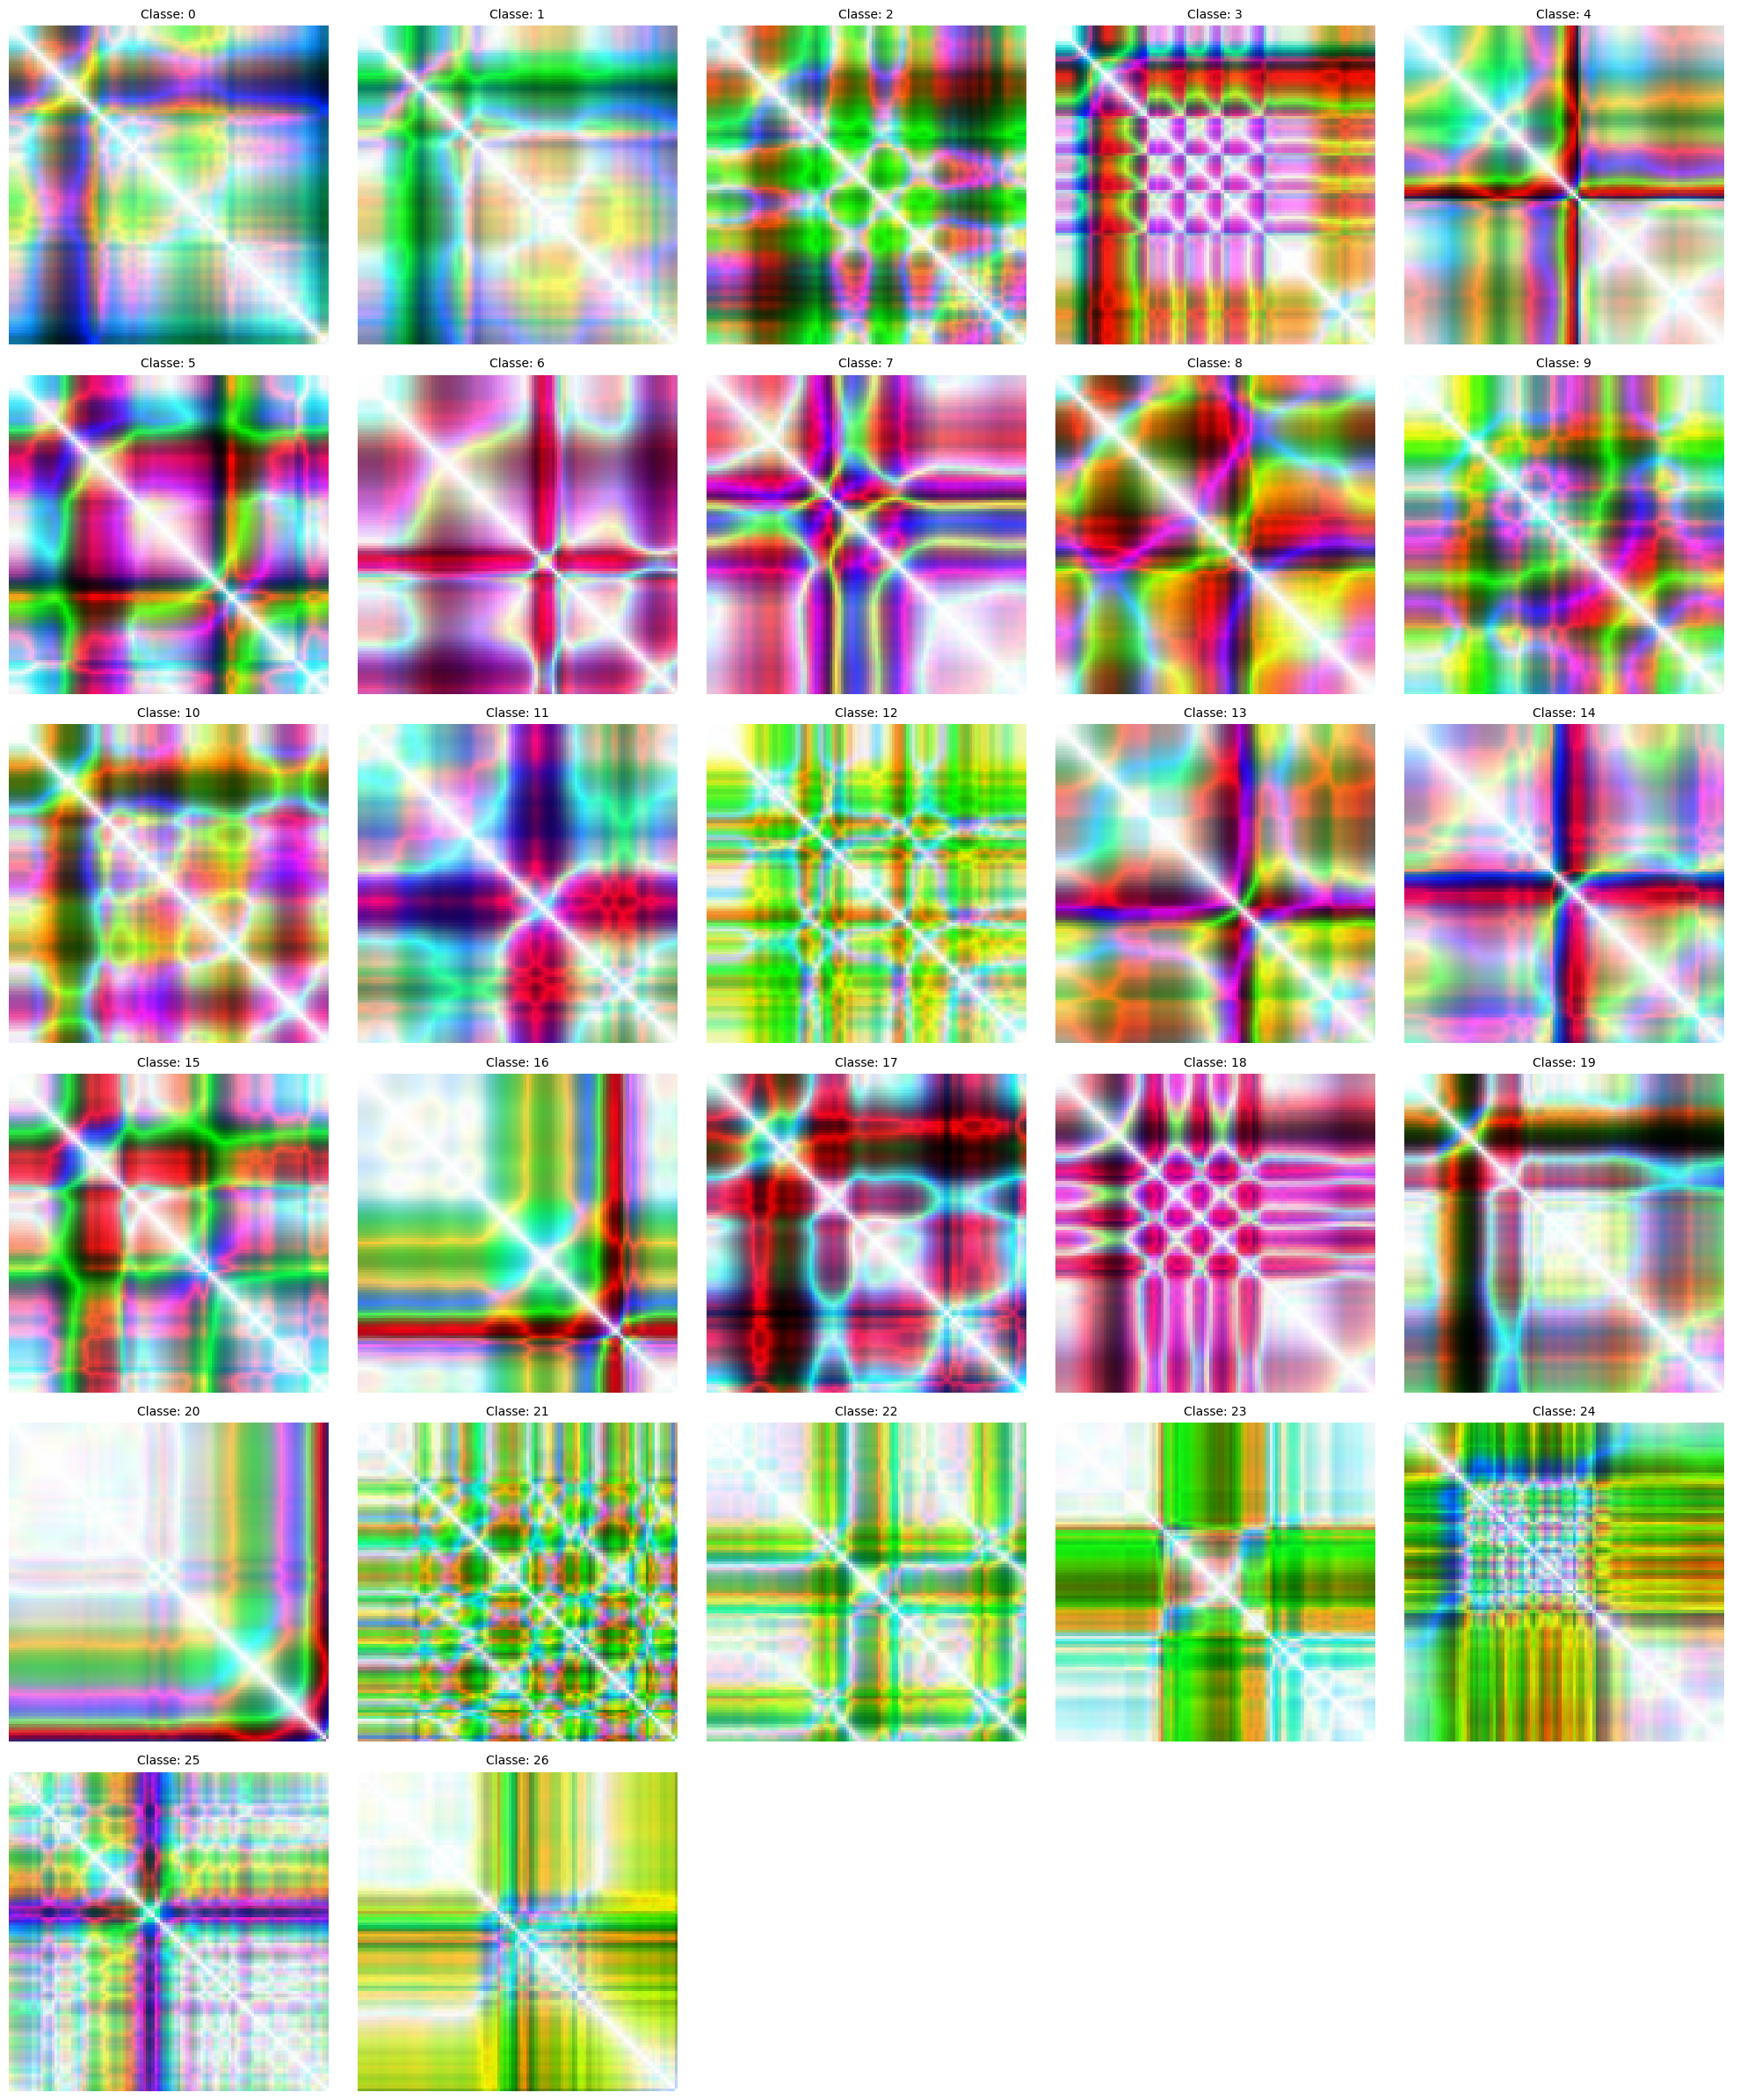

In [7]:
# ============================================================================
# EXPERIMENTO 2: OTIMIZAÇÃO COM OPTUNA
# ============================================================================
print("\n" + "="*50)
print("EXPERIMENTO 2: OTIMIZAÇÃO DE HIPERPARÂMETROS (OPTUNA)")
print("="*50)

def build_optuna_model(lr, dropout_rate, dense_units):
    l2_reg = tf.keras.regularizers.l2(0.01)

    # Ramo 1: ResNet
    input_img = layers.Input(shape=(112, 112, 3))
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False
    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(dense_units, activation='relu', kernel_regularizer=l2_reg)(x_img)
    x_img = layers.Dropout(dropout_rate)(x_img)

    # Ramo 2: CNN 1D
    input_1d = layers.Input(shape=(125, len(idx_others)))
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2_reg)(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2_reg)(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(dense_units // 2, activation='relu', kernel_regularizer=l2_reg)(x_1d)

    # Fusão
    merged = layers.concatenate([x_img, x_1d])
    z = layers.Dense(dense_units, activation='relu', kernel_regularizer=l2_reg)(merged)
    z = layers.Dropout(dropout_rate)(z)
    output = layers.Dense(num_classes, activation='softmax')(z)

    model_opt = models.Model(inputs=[input_img, input_1d], outputs=output)
    model_opt.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model_opt


def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])

    model_opt = build_optuna_model(lr, dropout_rate, dense_units)

    early_stopping_opt = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history_opt = model_opt.fit(
        x=[X_train_img, X_train_1d],
        y=y_train,
        validation_data=([X_val_img, X_val_1d], y_val),
        batch_size=32,
        epochs=10, # Poucas épocas para acelerar a busca
        class_weight=class_weights_dict,
        callbacks=[early_stopping_opt],
        verbose=0 # Silencia os logs de época por época do Optuna
    )

    val_acc = max(history_opt.history['val_accuracy'])
    return val_acc

# Criando e rodando o estudo
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("\nResultados da Busca do Optuna:")
print("Melhor Trial:")
trial = study.best_trial
print(f"  Valor (Val Accuracy): {trial.value:.4f}")
print("  Parâmetros:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# ============================================================================
# TREINANDO E AVALIANDO O MELHOR MODELO (EXPERIMENTO 2 FINAL)
# ============================================================================
print("\n" + "*"*50)
print("TREINANDO O MELHOR MODELO ENCONTRADO PELO OPTUNA")
print("*"*50)

best_lr = trial.params['lr']
best_dropout = trial.params['dropout_rate']
best_dense = trial.params['dense_units']

model_exp2 = build_optuna_model(best_lr, best_dropout, best_dense)

early_stopping_exp2 = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr_exp2 = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history_exp2 = model_exp2.fit(
    x=[X_train_img, X_train_1d],
    y=y_train,
    validation_data=([X_val_img, X_val_1d], y_val),
    batch_size=32,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_exp2, reduce_lr_exp2],
    verbose=1
)

# Chama a função de avaliação completa para o Experimento 2
evaluate_experiment(model_exp2, history_exp2, "Experimento 2 (Optuna Melhor Modelo)")

Calculando métricas para o Experimento 1 (Base)...
Calculando métricas para o Experimento 2 (Optuna)...

=== TABELA DE COMPARAÇÃO ===


,Cenário,Acurácia Média,F1-Score Médio
0,Experimento 1 (Base),0.467127,0.444622
1,Experimento 2 (Optuna),0.493082,0.454441


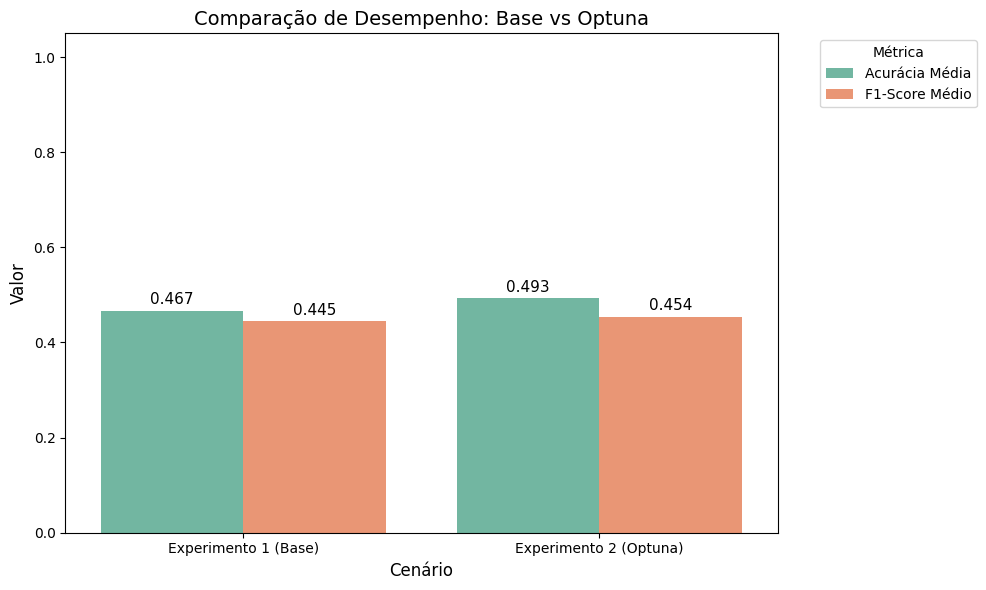

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample

# Função para calcular médias via bootstrap para ser fiel aos relatórios anteriores
def get_bootstrap_metrics(model, X_img, X_1d, y_true, n_iterations=100):
    y_pred_probs = model.predict([X_img, X_1d], batch_size=32, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc_scores = []
    f1_scores = []
    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)), replace=True)
        y_true_b = y_true[indices]
        y_pred_b = y_pred[indices]
        acc_scores.append(accuracy_score(y_true_b, y_pred_b))
        f1_scores.append(f1_score(y_true_b, y_pred_b, average='macro'))

    return np.mean(acc_scores), np.mean(f1_scores)

print("Calculando métricas para o Experimento 1 (Base)...")
acc_exp1, f1_exp1 = get_bootstrap_metrics(model_exp1, X_test_img, X_test_1d, y_test)

print("Calculando métricas para o Experimento 2 (Optuna)...")
acc_exp2, f1_exp2 = get_bootstrap_metrics(model_exp2, X_test_img, X_test_1d, y_test)

# 1. Tabela com os resultados
df_resultados = pd.DataFrame({
    'Cenário': ['Experimento 1 (Base)', 'Experimento 2 (Optuna)'],
    'Acurácia Média': [acc_exp1, acc_exp2],
    'F1-Score Médio': [f1_exp1, f1_exp2]
})

print("\n=== TABELA DE COMPARAÇÃO ===")
display(df_resultados)

# 2. Histograma / Gráfico de Barras
df_melted = df_resultados.melt(id_vars='Cenário', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Cenário', y='Valor', hue='Métrica', palette='Set2')
plt.title('Comparação de Desempenho: Base vs Optuna', fontsize=14)
plt.ylabel('Valor', fontsize=12)
plt.xlabel('Cenário', fontsize=12)
plt.ylim(0, 1.05)

# Adicionando os valores em cima das barras
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.3f}",
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', xytext=(0, 8),
                           textcoords='offset points', fontsize=11)

plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()